# Figure 5A -- Truncal SV comparison analysis

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, wilcoxon
from statsmodels.stats.proportion import proportion_confint


In [ ]:
SV_CLASSIFIED_PATH = "../../results_small_3bp/svs_classified.tsv"
CSV_EVENTS_PATH = "../../merged_clustered_sv_events.csv"
HOTSPOT_REGIONS = "../../../SV_Clone/hotspot_event_definitions.csv"

CHROM_MAP = {"X": "23", "Y": "24"}

# ---------------------------- CAUTION !!!-----------------------------------
#### This value is hardcoded and needs to be adapted from the results in Fig5a_GLMM.R ###
# GLMM significance 
GLMM_LRT_P = 5.824e-05 #<-- Calculate this with Fig5a_GLMM.R script first and adapt it if needed.


In [ ]:
# Helper functions
def extract_tumor_id(sample_name):
    sample_name = str(sample_name)
    if 'TARGET' in sample_name:
        return "-".join(sample_name.split('-')[:4])
    else:
        return sample_name.split("-")[0]

def normalize_chromosome(series):
    series = series.astype(str).replace(CHROM_MAP)
    return series.astype(int)


def annotate_hotspot_event(row, hotspots):
    mask_chrom = hotspots["chrom"] == row["chr"]
    mask_overlap = (row["start"] <= hotspots["end"]) & (row["end"] >= hotspots["start"])
    matched = hotspots.loc[mask_chrom & mask_overlap, "event"].unique()
    return ", ".join(matched) if len(matched) else None


def _breakpoint_in_regions(regions, chrom, pos):
    return (
        (regions["chr"] == chrom)
        & (pos >= regions["start"])
        & (pos <= regions["end"])
    ).any()


def check_is_clustered_sample(row, cgr_regions):
    regions = cgr_regions[cgr_regions["Tumor_ID"] == row["Tumor_ID"]]
    if regions.empty:
        return "No"
    hit1 = _breakpoint_in_regions(regions, row["chr1"], row["pos1"])
    hit2 = _breakpoint_in_regions(regions, row["chr2"], row["pos2"])
    return "Yes" if (hit1 or hit2) else "No"


def check_overlaps_hotspot_csv(row, cgr_regions):
    regions = cgr_regions[
        (cgr_regions["Tumor_ID"] == row["Tumor_ID"])
        & (cgr_regions["hotspot_event"].notna())
    ]
    if regions.empty:
        return "No"
    hit1 = _breakpoint_in_regions(regions, row["chr1"], row["pos1"])
    hit2 = _breakpoint_in_regions(regions, row["chr2"], row["pos2"])
    return "Yes" if (hit1 or hit2) else "No"


def get_hotspot_event_overlap(row, cgr_regions):
    regions = cgr_regions[
        (cgr_regions["Tumor_ID"] == row["Tumor_ID"])
        & (cgr_regions["hotspot_event"].notna())
    ]
    if regions.empty:
        return None

    mask1 = (
        (regions["chr"] == row["chr1"])
        & (row["pos1"] >= regions["start"])
        & (row["pos1"] <= regions["end"])
    )
    mask2 = (
        (regions["chr"] == row["chr2"])
        & (row["pos2"] >= regions["start"])
        & (row["pos2"] <= regions["end"])
    )
    hits = pd.concat([regions[mask1], regions[mask2]])["hotspot_event"].unique()
    return ", ".join(hits) if len(hits) else None


In [ ]:
# 1. Load data
sv_annotated = pd.read_csv(SV_CLASSIFIED_PATH, sep="\t")
hotspot_regions = pd.read_csv(HOTSPOT_REGIONS, sep=",")
cSVs_all = pd.read_csv(CSV_EVENTS_PATH, sep=",")

cSVs_all["Tumor_ID"] = cSVs_all["sample"].apply(extract_tumor_id)
cSVs_all["chr"] = normalize_chromosome(cSVs_all["chr"])

In [ ]:
# 2. Annotate clustered regions with overlapping hotspot events
cSVs_all["hotspot_event"] = cSVs_all.apply(
    lambda r: annotate_hotspot_event(r, hotspot_regions), axis=1
)

In [ ]:
# 3. Annotate every SV
sample_composition = sv_annotated.copy()
sample_composition["is_clustered"] = sample_composition.apply(
    lambda r: check_is_clustered_sample(r, cSVs_all), axis=1
)
sample_composition["is_hotspot_CGR"] = sample_composition.apply(
    lambda r: check_overlaps_hotspot_csv(r, cSVs_all), axis=1
)
sample_composition["Hotspot_Event"] = sample_composition.apply(
    lambda r: get_hotspot_event_overlap(r, cSVs_all), axis=1
)


In [ ]:
# 4. Restrict to clustered SVs, collapse clonality classes
clustered_SVs = sample_composition[sample_composition["is_clustered"] == "Yes"].copy()

clustered_SVs["clonality"] = clustered_SVs["clonality"].replace(
    ["shared", "private"], "others"
)

print(f"Total clustered SVs (SV-level, one row per sample): {len(clustered_SVs)}")
print(f"Unique tumor samples (Tumor_ID): {clustered_SVs['Tumor_ID'].nunique()}")
print(f"Unique patients (Normal_ID): {clustered_SVs['Normal_ID'].nunique()}")


Total clustered SVs (SV-level, one row per sample): 9568
Unique tumor samples (Tumor_ID): 47
Unique patients (Normal_ID): 20


In [ ]:
# 4b. De-duplicate: one row per physical SV per patient (Patient_ID is Normal_ID)
#     A shared/truncal SV is detected in multiple Tumor_ID samples belonging
#     to the same patient, but private SVs appear by definition only once. This
#     is why we need to deduplicate all SVs so that only one truncal/shared SV 
#     per patient remains and we do not inflate the statistic with to many SVs.
clonality_consistency = (
    clustered_SVs.groupby(["Normal_ID", "chr1", "pos1", "chr2", "pos2"])["clonality"]
    .nunique()
)
print("Clonality agreement across sibling samples for the same physical SV:")
print(clonality_consistency.value_counts())
if (clonality_consistency > 1).any():
    print(f"WARNING: {(clonality_consistency > 1).sum()} physical SVs have inconsistent "
          f"clonality calls across sibling samples -- inspect before trusting dedup below.")

dedup_SVs = clustered_SVs.drop_duplicates(
    subset=["Normal_ID", "chr1", "pos1", "chr2", "pos2", "is_hotspot_CGR"]
).copy()

print(f"\nRows before dedup: {len(clustered_SVs)}, after: {len(dedup_SVs)}")
print(f"Unique patients contributing de-duplicated clustered SVs: {dedup_SVs['Normal_ID'].nunique()}")


Clonality agreement across sibling samples for the same physical SV:
clonality
1    6194
2       1
Name: count, dtype: int64

Rows before dedup: 9568, after: 6244
Unique patients contributing de-duplicated clustered SVs: 20


In [34]:
reg_df = dedup_SVs.copy()
reg_df["truncal"] = (reg_df["clonality"] == "truncal").astype(int)
reg_df["hotspot"] = (reg_df["is_hotspot_CGR"] == "Yes").astype(int)
reg_df = reg_df[["Normal_ID", "truncal", "hotspot"]].dropna().rename(columns={"Normal_ID": "patient"})

print(f"\nFinal model dataframe: {len(reg_df)} unique clustered SVs, "
      f"{reg_df['patient'].nunique()} patients")

reg_df.to_csv("reg_df_for_glmm.csv", index=False)


Final model dataframe: 6244 unique clustered SVs, 20 patients


# Run glmm_truncal_sv_analysis.R

In [ ]:
# 3. Actual (observed) percentages -- pooled across all patients, within each region type
obs_df = reg_df.groupby("hotspot")["truncal"].mean().reset_index()
obs_df["pct_truncal"] = obs_df["truncal"] * 100
obs_df["pct_others"] = 100 - obs_df["pct_truncal"]
obs_df["group"] = obs_df["hotspot"].map({1: "Hotspot", 0: "Non-hotspot"})
obs_df["n_svs"] = obs_df["hotspot"].map(reg_df.groupby("hotspot").size())
obs_df = obs_df.set_index("group").loc[["Hotspot", "Non-hotspot"]]

print(obs_df[["n_svs", "pct_truncal", "pct_others"]])

             n_svs  pct_truncal  pct_others
group                                      
Hotspot       2602    40.699462   59.300538
Non-hotspot   3642    30.093355   69.906645


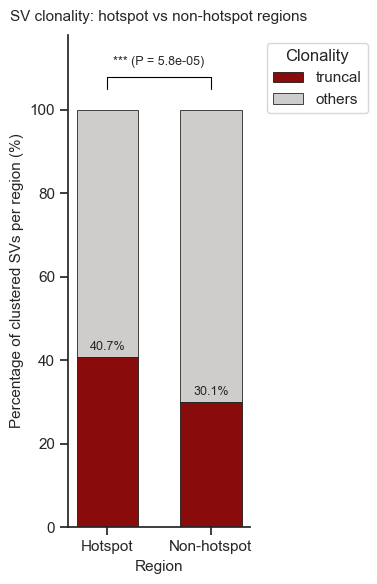

In [ ]:
# 4. Figure: actual %truncal / %others (stacked), hotspot vs non-hotspot, with GLMM likelihood-ratio-test significance stars.

sns.set_theme(style="ticks", rc={"axes.spines.right": False, "axes.spines.top": False})

def sig_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"

stars = sig_stars(GLMM_LRT_P)

plot_long = pd.DataFrame({
    "group": list(obs_df.index) * 2,
    "clonality": ["truncal"] * len(obs_df) + ["others"] * len(obs_df),
    "pct": list(obs_df["pct_truncal"]) + list(obs_df["pct_others"]),
})
plot_long["clonality"] = pd.Categorical(plot_long["clonality"], categories=["others", "truncal"])
plot_long = plot_long.sort_values(["group", "clonality"])

fig, ax = plt.subplots(figsize=(4, 6))

x_positions = {"Hotspot": 0, "Non-hotspot": 1}
colors = {"truncal": "#8a0b0b", "others": "#cfcccc"}

for group, x in x_positions.items():
    row = obs_df.loc[group]
    # others segment (bottom of stack)
    ax.bar(x, row["pct_truncal"], width=0.6, color=colors["truncal"],
           edgecolor="black", linewidth=0.5, label="truncal" if x == 0 else None)
    # truncal segment (stacked on top)
    ax.bar(x, row["pct_others"], bottom=row["pct_truncal"], width=0.6,
           color=colors["others"], edgecolor="black", linewidth=0.5,
           label="others" if x == 0 else None)
    # label at the truncal/others boundary
    ax.annotate(f"{row['pct_truncal']:.1f}%", (x, row["pct_truncal"]),
                ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontsize=9)

# significance bracket between the two bars
y_bracket = 108
ax.plot([0, 0, 1, 1], [y_bracket - 3, y_bracket, y_bracket, y_bracket - 3], color="black", linewidth=0.8)
ax.text(0.5, y_bracket + 2, f"{stars} (P = {GLMM_LRT_P:.2g})", ha="center", va="bottom", fontsize=9)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Hotspot", "Non-hotspot"])
ax.set_ylim(0, 118)
ax.set_ylabel("Percentage of clustered SVs per region (%)", fontsize=11)
ax.set_xlabel("Region", fontsize=11)
ax.set_title("SV clonality: hotspot vs non-hotspot regions", fontsize=11, pad=10)
ax.legend(title="Clonality", bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.savefig("Fig5A_actual_pct_glmm_sig.svg", format="svg")
plt.savefig("Fig5A_actual_pct_glmm_sig.pdf", format="pdf")
plt.show()

